# Домашнее задание №2

рынок: Франция <br>
период: 2023 год

Гайфиев Иван, <br>
Цирулёв Дмитрий, <br>
Прокопец Артём,<br>
23КНТ-6

In [9]:
!pip install PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 7.6 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier
from scipy.optimize import minimize
import seaborn as sns
from sklearn import decomposition
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
np.set_printoptions(precision=4, suppress=True)

# Константы
TRADING_DAYS = 255
RISK_FREE_RATE = 0.03523  # 3.5% годовых для Франции в 2023 (взято отсюда: https://www.investing.com/rates-bonds/france-10-year-bond-yield-historical-data)

risk_free_daily = RISK_FREE_RATE / TRADING_DAYS

# --- ЗАГРУЗКА ДАННЫХ ---
df = pd.read_csv('french_stocks_50.csv', sep=';', parse_dates=['Date'], dayfirst=True, decimal='.')
df.set_index('Date', inplace=True)

cac40_df = pd.read_csv('CAC40.csv', sep=';', encoding='utf-8-sig')
cac40_df['Date'] = pd.to_datetime(cac40_df['Date'], format='%d.%m.%Y')
cac40_df.set_index('Date', inplace=True)

# --- РАСЧЕТ ПАРАМЕТРОВ ---
log_returns = np.log(df / df.shift(1)).dropna()
market_returns = np.log(cac40_df / cac40_df.shift(1)).dropna()

# Параметры отдельных акций (ваша база)
stock_stat = pd.DataFrame()
stock_stat['E'] = log_returns.mean() * 255
stock_stat['Sigma'] = log_returns.std() * np.sqrt(255)

risk_free_rate = 0.035 # 3.5% годовых
stock_stat['sharp'] = (stock_stat['E'] - risk_free_rate) / stock_stat['Sigma']

print("Коэффициенты Шарпа (с безрисковой ставкой 3.5%):")
print(stock_stat['sharp'].sort_values(ascending=False))

# Общий портфель (равновесный для статистики)
portfolio_returns = log_returns.mean(axis=1)
portfolio_E = portfolio_returns.mean() * 255
portfolio_Sigma = portfolio_returns.std() * np.sqrt(255)
portfolio_sharp = (portfolio_E - risk_free_rate) / portfolio_Sigma

print(f"\nКоэффициент Шарпа портфеля: {portfolio_sharp:.4f}")

# Расчет годовых статистик
annual_mean_returns = log_returns.mean() * TRADING_DAYS
annual_cov_matrix = log_returns.cov() * TRADING_DAYS

# Данные для индекса CAC40
market_E = market_returns.iloc[:, 0].mean() * 255
market_Sigma = market_returns.iloc[:, 0].std() * np.sqrt(255)

# Матрицы для оптимизатора (annualized)
mean_vec = stock_stat['E'].values
cov_matrix = log_returns.cov().values * 255
r_matrix = log_returns.values

print(f"Базовые параметры рассчитаны. Активов: {len(stock_stat)}")

Коэффициенты Шарпа (с безрисковой ставкой 3.5%):
Stellantis NV                                         1.939992
DNXcorp SA                                            1.913892
IDI                                                   1.619750
Credit Agricole                                       1.615571
Accor                                                 1.612685
Viel et Cie SA                                        1.569012
Air Liquide                                           1.526676
Publicis                                              1.491932
Vicat                                                 1.453593
Safran                                                1.444418
L'Oreal                                               1.385414
Saint Gobain                                          1.379458
Voyageurs du Monde SA                                 1.336272
Groupe Guillin                                        1.321721
Quadient                                              1.309240
Roche 

### Задание 1: Efficient frontier.
Выбрать на рынке набор из 50 акций. Объясните ваш выбор (целью является
построение портфеля инвестиций из выбранных активов). Построить эффективный фронт портфелей
инвестиций без ограничений на короткие позиции и эффективный фронт с запретом коротких
позиций. Сравнить эффективные фронты и сделать выводы. При построении эффективных фронтов
вычислить портфели с минимальным риском и отметить их на соответствующем эффективном
фронте. Рассмотреть портфель с равными долями вложения капитала и оценить, как далек этот
портфель от эффективного фронта. Тот же вопрос для индекса рынка.

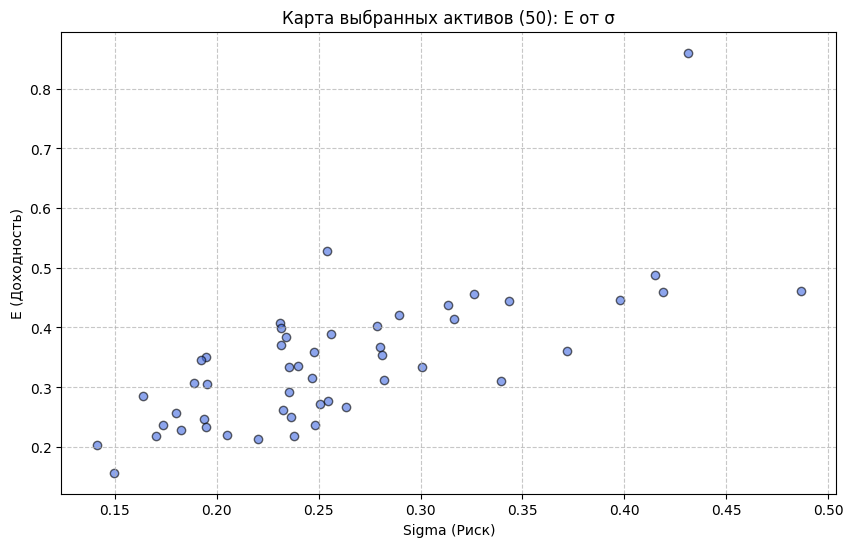

Запуск расчета фронта с шортами...
Запуск расчета фронта без шортов...
Все расчеты завершены!


In [11]:
def risk_porfolio(X, cov_matrix):
    """Расчет риска портфеля (Standard Deviation)"""
    return np.sqrt(np.dot(np.dot(X, cov_matrix), X.T))

def optimize_portfolio(risk_func, mean_returns, cov_matrix, bounds, target_return=None):
    """Универсальный оптимизатор для поиска портфеля"""
    num_assets = len(mean_returns)
    X = np.ones(num_assets) / num_assets # Начальное приближение (равные доли)

    # Базовое ограничение: сумма весов = 1
    constraints = [{'type': 'eq', 'fun': lambda X: np.sum(X) - 1.0}]

    # Если задана целевая доходность, добавляем ограничение
    if target_return is not None:
        constraints.append({'type': 'eq', 'fun': lambda X: np.dot(X, mean_returns) - target_return})

    result = minimize(risk_func, X, args=(cov_matrix,), method='SLSQP',
                      constraints=constraints, bounds=bounds)
    return result.x

def plot_mean_var_map(df, x='Sigma', y='E', title='Карта активов'):
    """Рисует карту всех акций без цветовой шкалы Шарпа"""
    plt.figure(figsize=(10, 6))
    # Убрали параметры 'c' и 'cmap', а также plt.colorbar()
    plt.scatter(df[x], df[y], alpha=0.6, color='royalblue', edgecolors='black')
    plt.xlabel('Sigma (Риск)')
    plt.ylabel('E (Доходность)')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)

plot_mean_var_map(stock_stat, title='Карта выбранных активов (50): E от σ')
plt.show()

# --- А) Эффективный фронт БЕЗ ограничений на шорты (Shorts Allowed) ---
print("Запуск расчета фронта с шортами...")
psigmas = []
preturns = []
bounds_short = tuple((None, None) for _ in range(len(mean_vec)))

# Портфель мин. риска
X_min_risk = optimize_portfolio(risk_porfolio, mean_vec, cov_matrix, bounds_short)
min_risk = risk_porfolio(X_min_risk, cov_matrix)
min_risk_preturn = np.dot(X_min_risk, mean_vec)

# Цикл расчета целевых доходностей
target_range = np.linspace(min_risk_preturn, mean_vec.max(), 50)
for tr in target_range:
    X = optimize_portfolio(risk_porfolio, mean_vec, cov_matrix, bounds_short, target_return=tr)
    psigmas.append(risk_porfolio(X, cov_matrix))
    preturns.append(np.dot(X, mean_vec))

# --- Б) Эффективный фронт С ЗАПРЕТОМ шортов (No Shorts) ---
print("Запуск расчета фронта без шортов...")
psigmas_ns = []
preturns_ns = []
bounds_no_short = tuple((0.0, 1.0) for _ in range(len(mean_vec)))

# Портфель мин. риска без шортов
X_min_risk_ns = optimize_portfolio(risk_porfolio, mean_vec, cov_matrix, bounds_no_short)
min_risk_ns = risk_porfolio(X_min_risk_ns, cov_matrix)
min_risk_preturn_ns = np.dot(X_min_risk_ns, mean_vec)

# Цикл расчета
target_range_ns = np.linspace(min_risk_preturn_ns, mean_vec.max(), 50)
for tr in target_range_ns:
    X_ns = optimize_portfolio(risk_porfolio, mean_vec, cov_matrix, bounds_no_short, target_return=tr)
    psigmas_ns.append(risk_porfolio(X_ns, cov_matrix))
    preturns_ns.append(np.dot(X_ns, mean_vec))

print("Все расчеты завершены!")

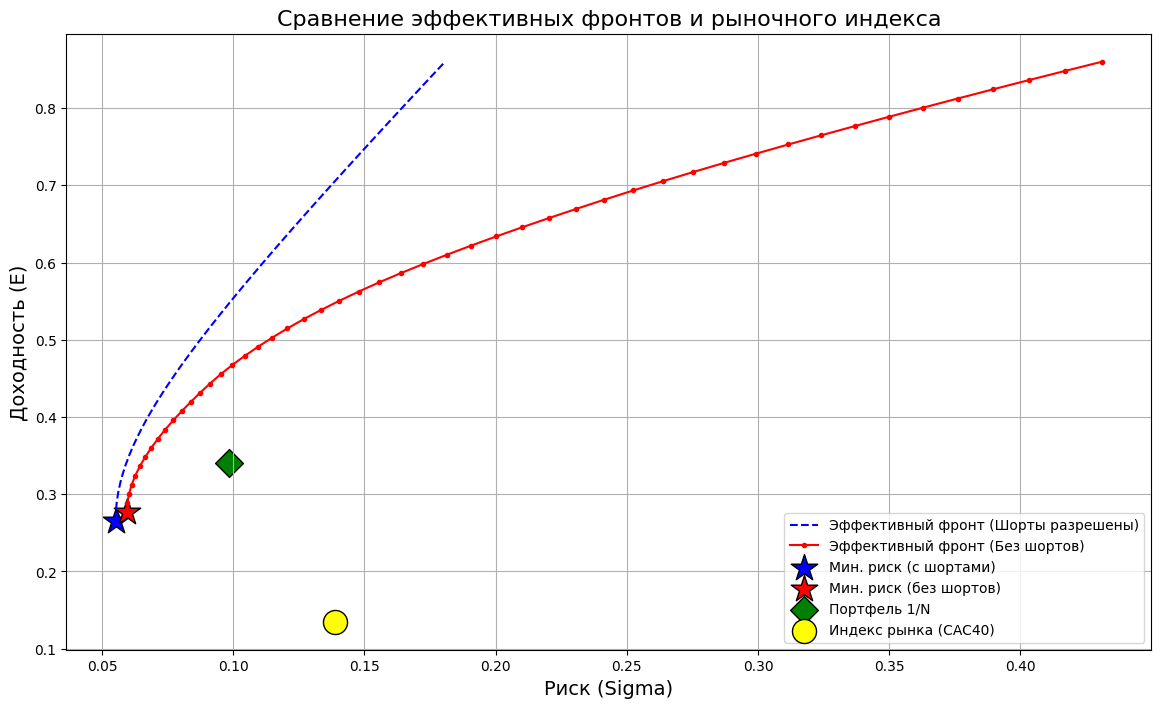


Выводы для Задания 1:
1. Доходность индекса CAC40: 0.1349, Риск: 0.1388
2. Доходность портфеля 1/N: 0.3406, Риск: 0.0985
3. Минимальный возможный риск без шортов: 0.0594
4. Запрет коротких позиций сужает область выбора, смещая фронт вправо (в сторону большего риска).


In [12]:
plt.figure(figsize=(14, 8))

# 1. Фронты
plt.plot(psigmas, preturns, 'b--', label='Эффективный фронт (Шорты разрешены)')
plt.plot(psigmas_ns, preturns_ns, 'r.-', label='Эффективный фронт (Без шортов)')

# 2. Точки минимального риска
plt.scatter(min_risk, min_risk_preturn, c='blue', marker='*', s=400, edgecolors='black', label='Мин. риск (с шортами)')
plt.scatter(min_risk_ns, min_risk_preturn_ns, c='red', marker='*', s=400, edgecolors='black', label='Мин. риск (без шортов)')

# 3. Портфель с равными долями
plt.scatter(portfolio_Sigma, portfolio_E, c='green', marker='D', s=200, edgecolors='black', label='Портфель 1/N')

# 4. Индекс рынка (CAC40)
plt.scatter(market_Sigma, market_E, c='yellow', marker='o', s=300, edgecolors='black', label='Индекс рынка (CAC40)')

plt.title('Сравнение эффективных фронтов и рыночного индекса', size=16)
plt.xlabel('Риск (Sigma)', size=14)
plt.ylabel('Доходность (E)', size=14)
plt.legend()
plt.grid(True)
plt.show()

print(f"\nВыводы для Задания 1:")
print(f"1. Доходность индекса CAC40: {market_E:.4f}, Риск: {market_Sigma:.4f}")
print(f"2. Доходность портфеля 1/N: {portfolio_E:.4f}, Риск: {portfolio_Sigma:.4f}")
print(f"3. Минимальный возможный риск без шортов: {min_risk_ns:.4f}")
print(f"4. Запрет коротких позиций сужает область выбора, смещая фронт вправо (в сторону большего риска).")

### Задание 2: Portfolio selection problem.
Требуется построить «хорошие» инвестиционные портфели из 10
активов вместо исходных 50 (или даже всех активов рынка). Предложите способ выбрать 10 активов
(из отобранных ранее 50) для формирования портфеля. Сравните эффективные фронты всего набора
(50 акций) и выбранного набора активов (10 акций) для двух случаев
- короткие продажи разрешены,
- короткие продажи запрещены.
Если результат сравнения показывает, что выбор 10 активов не очень удачный, подумайте, как
сделать лучший выбор.

In [13]:
def method_min_correlation(returns, n=10):
    """Метод минимальной средней корреляции"""
    corr_matrix = returns.corr().abs()
    avg_corr = (corr_matrix.sum(axis=1) - 1) / (corr_matrix.shape[1] - 1)
    return avg_corr.nsmallest(n).index.tolist()

def method_min_risk_portfolio(mu, cov_matrix, n=10):
    """Метод портфеля минимального риска"""
    ef = EfficientFrontier(mu, cov_matrix, weight_bounds=(0, 1))
    ef.min_volatility()
    weights = ef.clean_weights()
    sorted_weights = sorted(weights.items(), key=lambda x: x[1], reverse=True)
    return [ticker for ticker, _ in sorted_weights[:n]]

# Применение методов отбора
tickers_method1 = method_min_correlation(log_returns, 10)
tickers_method2 = method_min_risk_portfolio(annual_mean_returns, annual_cov_matrix, 10)

print("\nМетод минимальной корреляции:")
for i, ticker in enumerate(tickers_method1, 1):
    print(f"{i:2}. {ticker}")

print("\nМетод портфеля минимального риска:")
for i, ticker in enumerate(tickers_method2, 1):
    print(f"{i:2}. {ticker}")


Метод минимальной корреляции:
 1. Acanthe Developpement
 2. Lanson BCC SA
 3. Caisse Reg Cred Agric Mut Tourain Poitou
 4. NSE SA
 5. LDC
 6. IDI
 7. Viel et Cie SA
 8. Coheris
 9. Exacompta Clairefontaine
10. Groupe Pizzorno Environnement

Метод портфеля минимального риска:
 1. Orange
 2. Danone
 3. Patrimoine et Commerce
 4. IDI
 5. Lanson BCC SA
 6. LDC
 7. Linedata Services
 8. Viel et Cie SA
 9. Voyageurs du Monde SA
10. Caisse Regionale de Credit Agricole Mutuel Atlanti


In [14]:
def evaluate_method(tickers, mu_all, cov_all, rf_rate=RISK_FREE_RATE):
    """Оценка качества отбора активов"""
    mu = mu_all[tickers]
    cov = cov_all.loc[tickers, tickers]

    # Портфель максимального Шарпа
    ef = EfficientFrontier(mu, cov, weight_bounds=(0, 1))
    ef.max_sharpe(risk_free_rate=rf_rate)
    _, _, sharpe = ef.portfolio_performance(risk_free_rate=rf_rate)

    return sharpe

# Оценка методов
sharpe_method1 = evaluate_method(tickers_method1, annual_mean_returns, annual_cov_matrix)
sharpe_method2 = evaluate_method(tickers_method2, annual_mean_returns, annual_cov_matrix)

print(f"Коэффициент Шарпа для метода минимальной корреляции: {sharpe_method1:.4f}")
print(f"Коэффициент Шарпа для метода портфеля минимального риска: {sharpe_method2:.4f}")

# Выбор лучшего метода
if sharpe_method1 > sharpe_method2:
    best_tickers = tickers_method1
    best_method_name = "Минимальная корреляция"
    best_sharpe = sharpe_method1
else:
    best_tickers = tickers_method2
    best_method_name = "Портфель минимального риска"
    best_sharpe = sharpe_method2

print(f"\nЛучший метод - {best_method_name} - с коэффициентом Шарпа {best_sharpe:.4f}")

# Подготовка данных для выбранных активов
mu_selected = annual_mean_returns[best_tickers]
S_selected = annual_cov_matrix.loc[best_tickers, best_tickers]

print(f"\nВыбранные 10 активов (их годовая доходность):")
for i, ticker in enumerate(best_tickers, 1):
    annual_return = annual_mean_returns[ticker]
    print(f"{i:2}. {ticker:<50} ({annual_return:>6.2%})")

Коэффициент Шарпа для метода минимальной корреляции: 3.4390
Коэффициент Шарпа для метода портфеля минимального риска: 3.5999

Лучший метод - Портфель минимального риска - с коэффициентом Шарпа 3.5999

Выбранные 10 активов (их годовая доходность):
 1. Orange                                             (15.67%)
 2. Danone                                             (20.29%)
 3. Patrimoine et Commerce                             (22.85%)
 4. IDI                                                (35.02%)
 5. Lanson BCC SA                                      (26.18%)
 6. LDC                                                (31.48%)
 7. Linedata Services                                  (21.89%)
 8. Viel et Cie SA                                     (39.83%)
 9. Voyageurs du Monde SA                              (42.15%)
10. Caisse Regionale de Credit Agricole Mutuel Atlanti (21.27%)


In [15]:
def build_efficient_frontier_optimization(mu, cov_matrix, weight_bounds, n_points=30):
    """Построение эффективной границы методом оптимизации"""
    n_assets = len(mu)

    def portfolio_volatility(weights):
        return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Ограничения
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]

    # Границы весов
    if weight_bounds == (0, 1):
        bounds = tuple((0, 1) for _ in range(n_assets))
    else:  # Для коротких продаж
        bounds = tuple((-1, 1) for _ in range(n_assets))

    # Целевые доходности
    min_return = mu.min() * 0.9
    max_return = mu.max() * 1.1
    target_returns = np.linspace(min_return, max_return, n_points)
    frontier_returns = []
    frontier_risks = []
    for target_return in target_returns:
        # Добавляем ограничение на доходность
        constraints_with_return = constraints + [
            {'type': 'eq', 'fun': lambda x: np.dot(x, mu) - target_return}
        ]

        # Начальные веса (равномерное распределение)
        initial_weights = np.ones(n_assets) / n_assets

        # Оптимизация
        result = minimize(
            portfolio_volatility,
            initial_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints_with_return,
            options={'maxiter': 1000}
        )

        if result.success:
            frontier_risks.append(result.fun)
            frontier_returns.append(target_return)

    return np.array(frontier_returns), np.array(frontier_risks)

In [16]:
# Построение всех эффективных границ
er_50_no, sd_50_no = build_efficient_frontier_optimization(
    annual_mean_returns, annual_cov_matrix, (0, 1), n_points=30
)

er_50_short, sd_50_short = build_efficient_frontier_optimization(
    annual_mean_returns, annual_cov_matrix, (-1, 1), n_points=30
)

er_10_no, sd_10_no = build_efficient_frontier_optimization(
    mu_selected, S_selected, (0, 1), n_points=30
)

er_10_short, sd_10_short = build_efficient_frontier_optimization(
    mu_selected, S_selected, (-1, 1), n_points=30
)

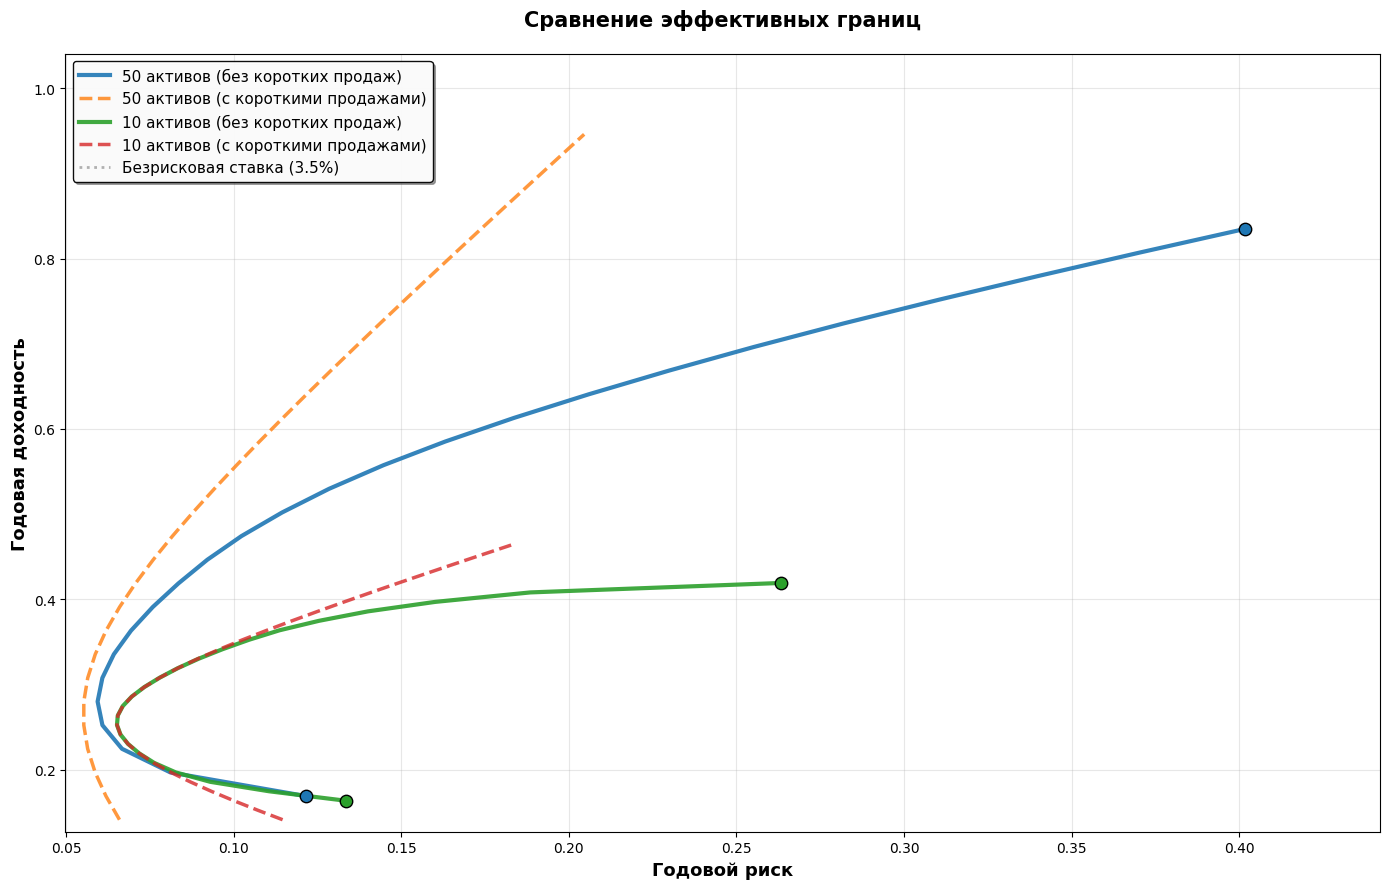

In [17]:
plt.figure(figsize=(14, 9))

# Цвета и стили для разных портфелей
colors = {
    '50_no': '#1f77b4',    # Синий для 50 активов без коротких
    '50_short': '#ff7f0e', # Оранжевый для 50 активов с короткими
    '10_no': '#2ca02c',    # Зеленый для 10 активов без коротких
    '10_short': '#d62728'  # Красный для 10 активов с короткими
}

# Построение всех линий
lines = []

# 50 активов (без коротких продаж)
if len(er_50_no) > 0:
    line_50_no, = plt.plot(sd_50_no, er_50_no, color=colors['50_no'],
                           linewidth=3, alpha=0.9, label='50 активов (без коротких продаж)')
    lines.append(line_50_no)
    # Маркеры для крайних точек
    plt.scatter(sd_50_no[0], er_50_no[0], color=colors['50_no'], s=80,
                edgecolor='black', zorder=5)
    plt.scatter(sd_50_no[-1], er_50_no[-1], color=colors['50_no'], s=80,
                edgecolor='black', zorder=5)

# 50 активов (с короткими продажами)
if len(er_50_short) > 0:
    line_50_short, = plt.plot(sd_50_short, er_50_short, color=colors['50_short'],
                             linewidth=2.5, linestyle='--', alpha=0.8,
                             label='50 активов (с короткими продажами)')
    lines.append(line_50_short)

# 10 активов (без коротких продаж)
if len(er_10_no) > 0:
    line_10_no, = plt.plot(sd_10_no, er_10_no, color=colors['10_no'],
                          linewidth=3, alpha=0.9, label='10 активов (без коротких продаж)')
    lines.append(line_10_no)
    # Маркеры для крайних точек
    plt.scatter(sd_10_no[0], er_10_no[0], color=colors['10_no'], s=80,
                edgecolor='black', zorder=5)
    plt.scatter(sd_10_no[-1], er_10_no[-1], color=colors['10_no'], s=80,
                edgecolor='black', zorder=5)

# 10 активов (с короткими продажами)
if len(er_10_short) > 0:
    line_10_short, = plt.plot(sd_10_short, er_10_short, color=colors['10_short'],
                             linewidth=2.5, linestyle='--', alpha=0.8,
                             label='10 активов (с короткими продажами)')
    lines.append(line_10_short)

# Линия безрисковой ставки
plt.axhline(y=RISK_FREE_RATE, color='gray', linestyle=':', linewidth=2,
           alpha=0.6, label=f'Безрисковая ставка ({RISK_FREE_RATE:.1%})')

# Настройки графика
plt.xlabel('Годовой риск', fontsize=13, fontweight='bold')
plt.ylabel('Годовая доходность', fontsize=13, fontweight='bold')
plt.title('Сравнение эффективных границ', fontsize=15, fontweight='bold', pad=20)
legend = plt.legend(fontsize=11, loc='upper left', frameon=True,
                    fancybox=True, shadow=True, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
plt.grid(True, alpha=0.3, linestyle='-')

# Автоматическое определение границ
all_sd = []
all_er = []
for sd, er in [(sd_50_no, er_50_no), (sd_50_short, er_50_short),
               (sd_10_no, er_10_no), (sd_10_short, er_10_short)]:
    if len(sd) > 0:
        all_sd.extend(sd)
        all_er.extend(er)
if all_sd and all_er:
    plt.xlim([min(all_sd) * 0.9, max(all_sd) * 1.1])
    plt.ylim([min(all_er) * 0.9, max(all_er) * 1.1])

plt.tight_layout()


In [18]:
def optimize_portfolio(mu, cov, objective='min_volatility', rf_rate=RISK_FREE_RATE):
    """Оптимизация портфеля с заданной целью"""
    ef = EfficientFrontier(mu, cov, weight_bounds=(0, 1))

    if objective == 'min_volatility':
        ef.min_volatility()
    elif objective == 'max_sharpe':
        ef.max_sharpe(risk_free_rate=rf_rate)

    weights = ef.clean_weights()
    ret, vol, sharpe = ef.portfolio_performance(risk_free_rate=rf_rate)

    return weights, ret, vol, sharpe

# Портфель минимального риска
weights_min, ret_min, vol_min, sharpe_min = optimize_portfolio(
    mu_selected, S_selected, 'min_volatility', RISK_FREE_RATE
)
print("\nПортфель минимального риска:")
for ticker, weight in sorted(weights_min.items(), key=lambda x: x[1], reverse=True):
    print(f" {ticker[:50]:50} {weight:>7.2%}")
print(f"Ожидаемая доходность: {ret_min:.2%}")
print(f"Ожидаемый риск: {vol_min:.2%}")
print(f"Коэффициент Шарпа: {sharpe_min:.4f}")

# Портфель максимального коэффициента Шарпа
weights_max, ret_max, vol_max, sharpe_max = optimize_portfolio(
    mu_selected, S_selected, 'max_sharpe', RISK_FREE_RATE
)
print("\nПортфель максимального коэффициента Шарпа:")
for ticker, weight in sorted(weights_max.items(), key=lambda x: x[1], reverse=True):
    print(f" {ticker[:50]:50} {weight:>7.2%}")
print(f"Ожидаемая доходность: {ret_max:.2%}")
print(f"Ожидаемый риск: {vol_max:.2%}")
print(f"Коэффициент Шарпа: {sharpe_max:.4f}")


Портфель минимального риска:
 Danone                                              17.35%
 Orange                                              15.65%
 Patrimoine et Commerce                              13.68%
 IDI                                                 10.74%
 LDC                                                  8.82%
 Lanson BCC SA                                        8.18%
 Linedata Services                                    7.91%
 Voyageurs du Monde SA                                6.08%
 Caisse Regionale de Credit Agricole Mutuel Atlanti   5.96%
 Viel et Cie SA                                       5.62%
Ожидаемая доходность: 25.58%
Ожидаемый риск: 6.51%
Коэффициент Шарпа: 3.3880

Портфель максимального коэффициента Шарпа:
 IDI                                                 15.52%
 Danone                                              13.91%
 Patrimoine et Commerce                              11.90%
 LDC                                                 10.42%
 Viel et 

In [19]:
# Оптимизация для полного портфеля
weights_full_min, ret_full_min, vol_full_min, sharpe_full_min = optimize_portfolio(
    annual_mean_returns, annual_cov_matrix, 'min_volatility', RISK_FREE_RATE
)

weights_full_max, ret_full_max, vol_full_max, sharpe_full_max = optimize_portfolio(
    annual_mean_returns, annual_cov_matrix, 'max_sharpe', RISK_FREE_RATE
)

print("Портфель из 50 активов:")
print(f"Портфель минимального риска:")
print(f"- Доходность: {ret_full_min:.2%}, Риск: {vol_full_min:.2%}, Шарп: {sharpe_full_min:.4f}")
print(f"Портфель максимального Шарпа:")
print(f"- Доходность: {ret_full_max:.2%}, Риск: {vol_full_max:.2%}, Шарп: {sharpe_full_max:.4f}")

print(f"\nПортфель из выбранных 10 активов:")
print(f"Портфель минимального риска:")
print(f"- Доходность: {ret_min:.2%}, Риск: {vol_min:.2%}, Шарп: {sharpe_min:.4f}")
print(f"Портфель максимального Шарпа:")
print(f"- Доходность: {ret_max:.2%}, Риск: {vol_max:.2%}, Шарп: {sharpe_max:.4f}")

print(f"\nОтносительная эффективность:")
print(f"По коэффициенту Шарпа: {sharpe_max/sharpe_full_max*100:.1f}% от полного портфеля")
print(f"По минимальному риску: {vol_min/vol_full_min*100:.1f}% от полного портфеля")

# Анализ диверсификации
corr_matrix = log_returns[best_tickers].corr()
avg_correlation = corr_matrix.values[np.triu_indices(len(best_tickers), k=1)].mean()
print(f"Средняя корреляция между выбранными активами: {avg_correlation:.4f}")

Портфель из 50 активов:
Портфель минимального риска:
- Доходность: 27.67%, Риск: 5.94%, Шарп: 4.0671
Портфель максимального Шарпа:
- Доходность: 36.35%, Риск: 6.94%, Шарп: 4.7282

Портфель из выбранных 10 активов:
Портфель минимального риска:
- Доходность: 25.58%, Риск: 6.51%, Шарп: 3.3880
Портфель максимального Шарпа:
- Доходность: 28.43%, Риск: 6.92%, Шарп: 3.5999

Относительная эффективность:
По коэффициенту Шарпа: 76.1% от полного портфеля
По минимальному риску: 109.7% от полного портфеля
Средняя корреляция между выбранными активами: 0.0084


### Задание 3: Risk aversion.
Оцените свое отношение к риску и постройте свой личный оптимальный портфель
инвестиций из выбранных 50 активов. Дайте характеристику портфеля по составу и долям активов.
Оцените VaR и CVaR портфеля. Сделайте выводы. Рассмотрите два случая:
- короткие продажи разрешены,
- короткие продажи запрещены.

### Решение:


In [21]:
# SOME NECESSARY VARIABLES
stocks_50 = pd.read_csv("/content/french_stocks_50.csv", sep=";")
selected_stocks_10 = pd.read_csv("/content/selected_stocks_10.csv", sep=";")
cac = pd.read_csv("/content/CAC40.csv",sep=";")
stocks_50 = stocks_50.dropna()
selected_stocks_50 = selected_stocks_10.dropna()
cac = cac.dropna()

# SOME NECESSARY FUNCTIONS
# Get lognormal returns
log_returns = (np.log(stocks_50.iloc[:,1:]/stocks_50.iloc[:,1:].shift(1))).dropna()

# Calculate covariance matrix
cov_matr = log_returns.cov()*254 # 254 working market days per year

# Calculate standard deviation
def std_dev(cov_matr, weights):
    variance = weights @ cov_matr @ weights.T
    return np.sqrt(variance)

# Calculate expected returns
def exp_ret(log_ret, weights=None):
    return np.sum(log_ret.mean()*weights)*254 # annual

# Calculate the Sharpe Ratio (without risk_free_rate)
def sharp_rat(weights, log_ret, cov_matr):
    return (exp_ret(log_ret, weights) / std_dev(cov_matr, weights))

# Calculate Value at Risk
def portfolio_var(weights, log_returns, beta=0.95):
    portfolio_returns = log_returns @ weights
    losses = -portfolio_returns
    VaR = losses.quantile(beta)
    return VaR

# Calculate Conditional Value at Risk
def portfolio_cvar(weights, log_returns, beta):
    portfolio_returns = log_returns @ weights
    losses = -portfolio_returns
    CVaR = losses[losses.ge(portfolio_var(weights, log_returns, beta))].mean()
    return CVaR

При неприятии риска мы хотим построить оптимальный портфель, который будет основан на нашем отношении к риску. <br>
Для этого мы составляем задачу квадратичной оптимизации: <br>
$$ U(w) = E(w) - \alpha\sigma^2(w) -> max $$
где $$ \Sigma w_i=1$$ и $$w_i \geq 0$$ если короткие продажи запрещены


In [22]:
# RISK AVERSION
def utility_func(weights, log_ret, cov_matr, alpha):
  return (exp_ret(log_ret, weights) - alpha * std_dev(cov_matr, weights))

def neg_utility(weights, log_ret, cov_matr, alpha):
  return -utility_func(weights, log_ret, cov_matr, alpha)

# OPTIMIZATION PROCESS
# Set constraints
constraints = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
bounds_s = [(-1, 1) for _ in range(len(log_returns.columns))] # short positions are allowed
bounds_l = [(0, 1) for _ in range(len(log_returns.columns))] # short positions are not allowed
alphas = [0, 1, 3, 5, 10]
alpha = 5 # greater = less risky portfolio.

# Set initial weights
initial_weights = np.array([1/len(log_returns.columns)] * len(log_returns.columns))

# SHORT POSITIONS ARE RESTRICTED
# Optimize weights to maximize Utility
# SLSQ - Sequential Least Squares Quadratic Programming
optimized_results = minimize(neg_utility, initial_weights, args=(log_returns, cov_matr, alpha), method='SLSQP', constraints=constraints, bounds=bounds_l)
optimal_weights = optimized_results.x

In [23]:
# PRINTING OPTIMIZATION RESULTS
print('Optimal weights:')

optimal_portfolio_return = exp_ret(log_returns, optimal_weights)
optimal_portfolio_volatility = std_dev(cov_matr, optimal_weights)
optimal_utility = utility_func(optimal_weights, log_returns, cov_matr, alpha)
optimal_sharp_ratio = sharp_rat(optimal_weights, log_returns, cov_matr)

print(f"Risk aversion coefficient: alpha = {alpha}")
print(f"Expected annual return: {optimal_portfolio_return:.4f}")
print(f"Expected volatility: {optimal_portfolio_volatility:.4f}")
print(f"Utility Value: {optimal_utility:.4f}")
print(f"Sharp Ratio: {optimal_sharp_ratio:.4f}")

Optimal weights:
Risk aversion coefficient: alpha = 5
Expected annual return: 0.3555
Expected volatility: 0.0679
Utility Value: 0.0158
Sharp Ratio: 5.2327


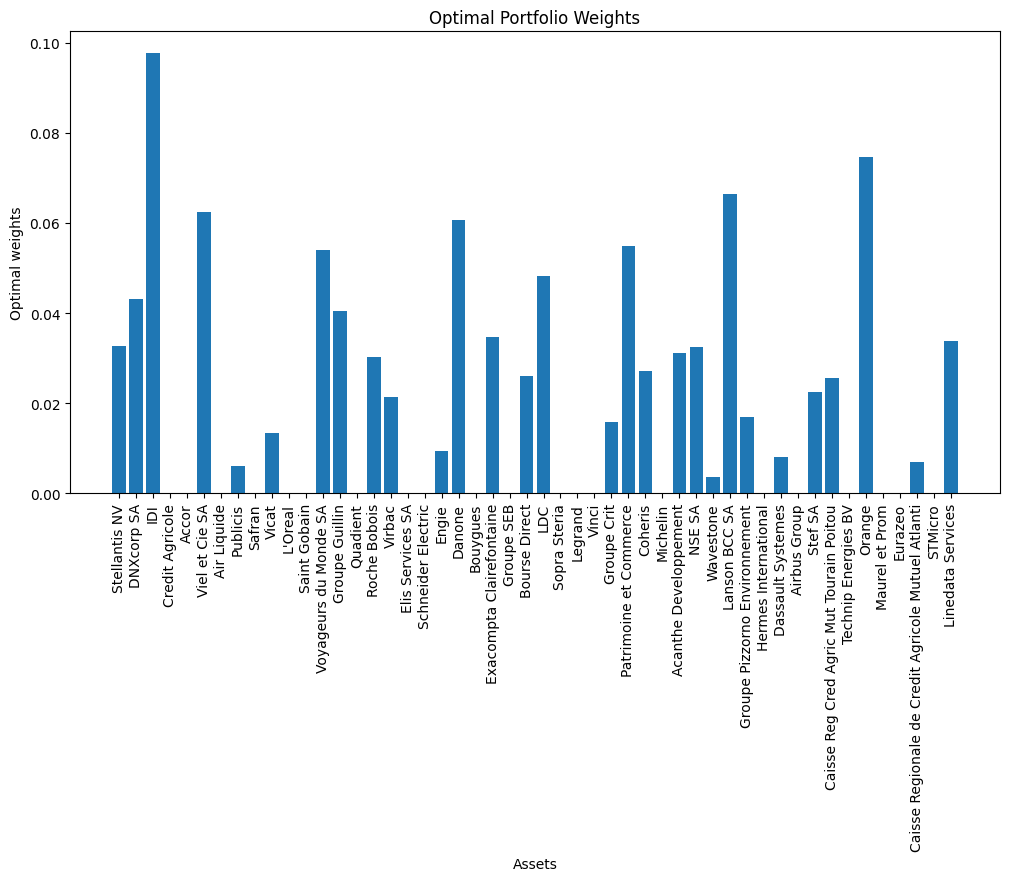

In [24]:
# DISPLAY OPTIMIZATION RESULTS
plt.figure(figsize=(12,6))
plt.bar(log_returns.columns, optimal_weights)

plt.xlabel('Assets')
plt.xticks(rotation=90)
plt.ylabel('Optimal weights')
plt.title('Optimal Portfolio Weights')

plt.show()

In [25]:
# Estimate VaR and CVaR
def var_info(initial_weights, log_returns, cov_matr, alphas, short):
  if short == False:
    bounds = bounds_l
  else:
    bounds = bounds_s
  for alpha in alphas:
    beta = [0.9, 0.95, 0.99]
    print(f"Estimation of VaR for optimal portfolio with risk level = {alpha}")
    for b in beta:
      optimized_results = minimize(neg_utility, initial_weights, args=(log_returns, cov_matr, alpha), method='SLSQP', constraints=constraints, bounds=bounds)
      optimal_weights = optimized_results.x
      optimal_var = portfolio_var(optimal_weights, log_returns, b)
      print(f" - With probability = {b*100}% looses will not exceed {optimal_var:.4f}.")

def cvar_info(initial_weights, log_returns, cov_matr, alphas, short):
   if short == False:
      bounds = bounds_l
   else:
      bounds = bounds_s
   for alpha in alphas:
      beta = [0.9, 0.95, 0.99]
      print(f"Estimation of CVaR for optimal portfolio with risk level = {alpha}")
      for b in beta:
          optimized_results = minimize(neg_utility, initial_weights, args=(log_returns, cov_matr, alpha), method='SLSQP', constraints=constraints, bounds=bounds)
          optimal_weights = optimized_results.x
          optimal_cvar = portfolio_cvar(optimal_weights, log_returns, b)
          print(f" - For VaR with probability {b*100}% value of CVaR = {optimal_cvar:.4f}.")

In [26]:
var_info(initial_weights, log_returns, cov_matr, alphas, False)
print("\n"+"-"*10+"\n")
cvar_info(initial_weights, log_returns, cov_matr, alphas, False)

Estimation of VaR for optimal portfolio with risk level = 0
 - With probability = 90.0% looses will not exceed 0.0250.
 - With probability = 95.0% looses will not exceed 0.0360.
 - With probability = 99.0% looses will not exceed 0.0563.
Estimation of VaR for optimal portfolio with risk level = 1
 - With probability = 90.0% looses will not exceed 0.0186.
 - With probability = 95.0% looses will not exceed 0.0244.
 - With probability = 99.0% looses will not exceed 0.0341.
Estimation of VaR for optimal portfolio with risk level = 3
 - With probability = 90.0% looses will not exceed 0.0055.
 - With probability = 95.0% looses will not exceed 0.0076.
 - With probability = 99.0% looses will not exceed 0.0143.
Estimation of VaR for optimal portfolio with risk level = 5
 - With probability = 90.0% looses will not exceed 0.0038.
 - With probability = 95.0% looses will not exceed 0.0056.
 - With probability = 99.0% looses will not exceed 0.0103.
Estimation of VaR for optimal portfolio with risk le

#### Характеристика портфеля (короткие продажи запрещены):
1) Портфель с коэффициентом отверждения риска = 5 представляет собой комбинацию активов из отобранных 50 компаний французского рынка с умеренно низким риском.
2) Портфель в себе содержит такие компании, как IDI, Danone, Orange которые имеют низкий уровень риска относительно других выбранных компаний на рынке. Это говорит о том, что наш портфель смещён в сторону более стабильных активов, следуя умеренно-консервативной стратегии.
IDI - компания, занимающаяся инвестициями в малый и средний бизнес на протяжении уже более 50 лет.
Danone - специализируется на продуктах, особенно молочных и растительных.
Orange - межнациональная телекоммуникационная компания, предоставляющая доступ к разным видам связи не только в Европе, но и в Африке и средней Азии.
3) Стоит также отметить, что портфель характеризуется диверсифицированной структурой, что говорит о включении в состав множества разных активов, как низкорисковых, так и высокорисковых: DNXvorp SA, Coheris, NSE SA, но в ограниченном количестве (их доля в портфеле ниже, чем у низкорисковых).
4) VaR постепенно снижается с увеличением коэффициента: от значения 0.0360 при полном безразличии к риску (с вероятностью равной 0.95) до 0.0055 при высоком значении отвержения риска. Это говорит о том, что при изменении нашего отношения к риску состав портфеля закономерно меняется, увеличивая или уменьшая долю рисковых атиквов.
<br>

In [27]:
# this function helps to calculate various portfolio statistics for visualization
def portfolio_info(initial_weights, log_returns, cov_matr, alphas, short):
  if short == False:
      bounds = bounds_l
  else:
      bounds = bounds_s

  data = {
        'risk_coefficient': [],
        'portfolio_weights': [],
        'expected_return': [],
        'portfolio_risk': [],
        'utility': []
    }
  for alpha in alphas:
    optimized_results = minimize(neg_utility, initial_weights, args=(log_returns, cov_matr, alpha), method='SLSQP', constraints=constraints, bounds=bounds)
    optimal_weights = optimized_results.x
    optimal_ret = exp_ret(log_returns, optimal_weights)
    optimal_volat = std_dev(cov_matr, optimal_weights)
    optimal_utility = utility_func(optimal_weights, log_returns, cov_matr, alpha)

    data['risk_coefficient'].append(alpha)
    data['portfolio_weights'].append(optimal_weights)
    data['expected_return'].append(optimal_ret)
    data['portfolio_risk'].append(optimal_volat)
    data['utility'].append(optimal_utility)

  df_results = pd.DataFrame(data)
  df_results.set_index('risk_coefficient', inplace=True)

  return df_results

def many_portfolios(initial_weights, log_returns, cov_matr, alphas, num_portf, short):
  if short == False:
      bounds = bounds_l
  else:
      bounds = bounds_s

  returns, volats = [], []

  for alpha in np.linspace(alphas[0], alphas[-1], num_portf):
    optimized_results = minimize(neg_utility, initial_weights, args=(log_returns, cov_matr, alpha), method='SLSQP', constraints=constraints, bounds=bounds)
    optimal_weights = optimized_results.x
    optimal_ret = exp_ret(log_returns, optimal_weights)
    optimal_volat = std_dev(cov_matr, optimal_weights)
    returns.append(optimal_ret)
    volats.append(optimal_volat)

  return returns, volats

In [28]:
# VISUALAZATION
# Map of stocks with efficient frontier and 4 optimal portfolios

# Some important variables
returns_mean = log_returns.mean()*254
returns_std = log_returns.std()*np.sqrt(254)
asset_names = log_returns.columns.values
portf_info = portfolio_info(initial_weights, log_returns, cov_matr, alphas, False)

idx = np.argsort(portf_info['portfolio_risk'])
risk_sorted = portf_info['portfolio_risk'].iloc[idx].values
return_sorted = portf_info['expected_return'].iloc[idx].values
many_ret, many_vol = many_portfolios(initial_weights, log_returns, cov_matr, alphas, 20, False)

In [29]:
# assets
def visualize(alphas, returns_std, returns_mean, asset_names, portf_info, risk_sorted, return_sorted, many_ret, many_vol):
  plt.figure(figsize=(16,8))
  plt.scatter(
      returns_std,
      returns_mean,
      marker = "o",
      s=100,
      label = "Assets"
  )
  for i, name in enumerate(asset_names):
    plt.text(returns_std[i], returns_mean[i], name)

  # optimal portfolios
  plt.scatter(
      portf_info["portfolio_risk"],
      portf_info["expected_return"],
      s=100,
      alpha=0.3,
      label="Portfolios"
  )

  for i in range(len(risk_sorted)-1):
    plt.annotate(f"Alpha = {alphas[len(alphas)-i-1]}", (risk_sorted[i], return_sorted[i]))

  # efficient frontier
  plt.plot(
      many_vol,
      many_ret,
      linestyle="--",
      color="orange",
      label="Efficient Frontier"
  )

  plt.xlabel("Risk(variance)")
  plt.ylabel("Expected return")
  plt.title("Stocks map with efficient frontier and 4 optimal portfolios with different risk aversion")
  plt.legend()
  plt.grid(True)
  plt.show()

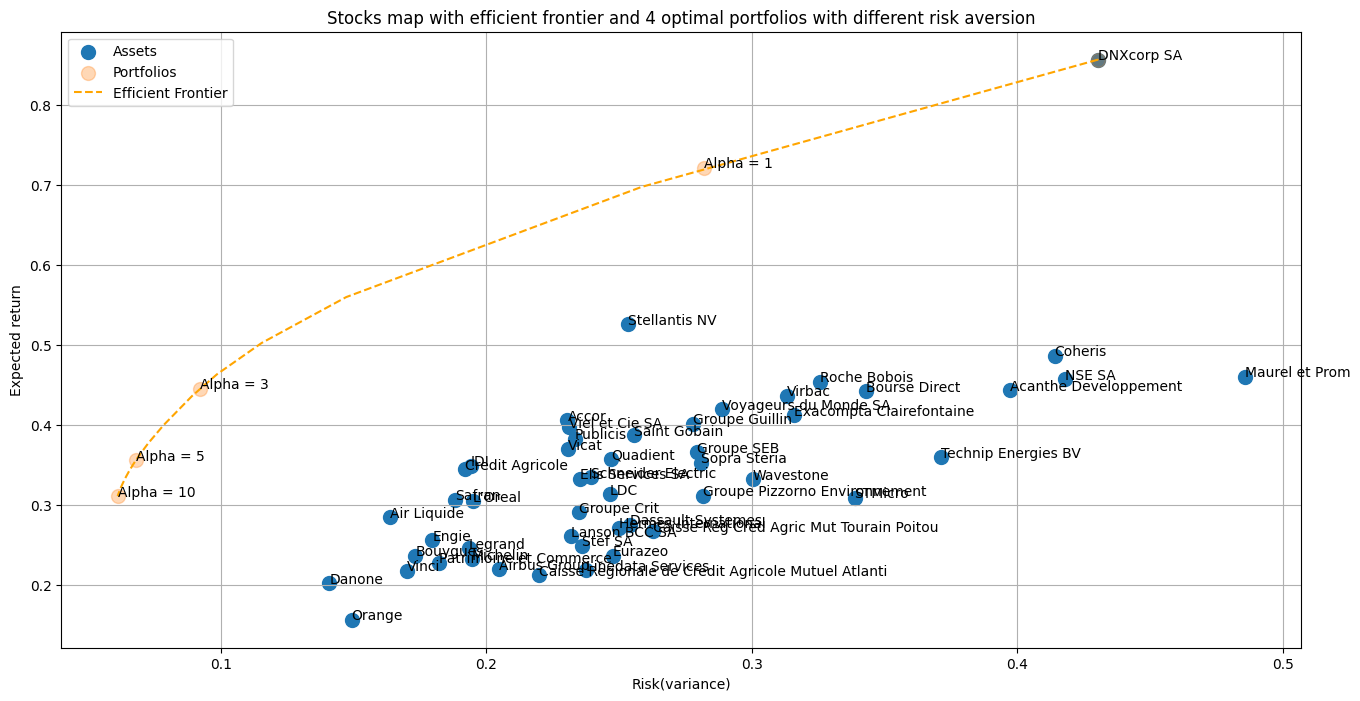

In [30]:
visualize(alphas, returns_std, returns_mean, asset_names, portf_info, risk_sorted, return_sorted, many_ret, many_vol)

Наш эффективный фронт портфелей без коротких продаж заканчивается активом DNXcorp SA в точке с уровнем отверждения риска = 0. Этот портфель является одновременно самым высокодоходным и в то же время наиболее рисковым.

In [31]:
# SHORT POSITIONS ARE PERMITTED
alphas = [3, 4, 5, 10]
optimized_results = minimize(neg_utility, initial_weights, args=(log_returns, cov_matr, alpha), method='SLSQP', constraints=constraints, bounds=bounds_s)
optimal_weights = optimized_results.x

# PRINTING OPTIMIZATION RESULTS
print('Optimal weights:')

optimal_portfolio_return = exp_ret(log_returns, optimal_weights)
optimal_portfolio_volatility = std_dev(cov_matr, optimal_weights)
optimal_utility = utility_func(optimal_weights, log_returns, cov_matr, alpha)
optimal_sharp_ratio = sharp_rat(optimal_weights, log_returns, cov_matr)

print(f"Risk aversion coefficient: alpha = {alpha}")
print(f"Expected annual return: {optimal_portfolio_return:.4f}")
print(f"Expected volatility: {optimal_portfolio_volatility:.4f}")
print(f"Utility Value: {optimal_utility:.4f}")
print(f"Sharp Ratio: {optimal_sharp_ratio:.4f}")

Optimal weights:
Risk aversion coefficient: alpha = 5
Expected annual return: 0.4453
Expected volatility: 0.0760
Utility Value: 0.0655
Sharp Ratio: 5.8626


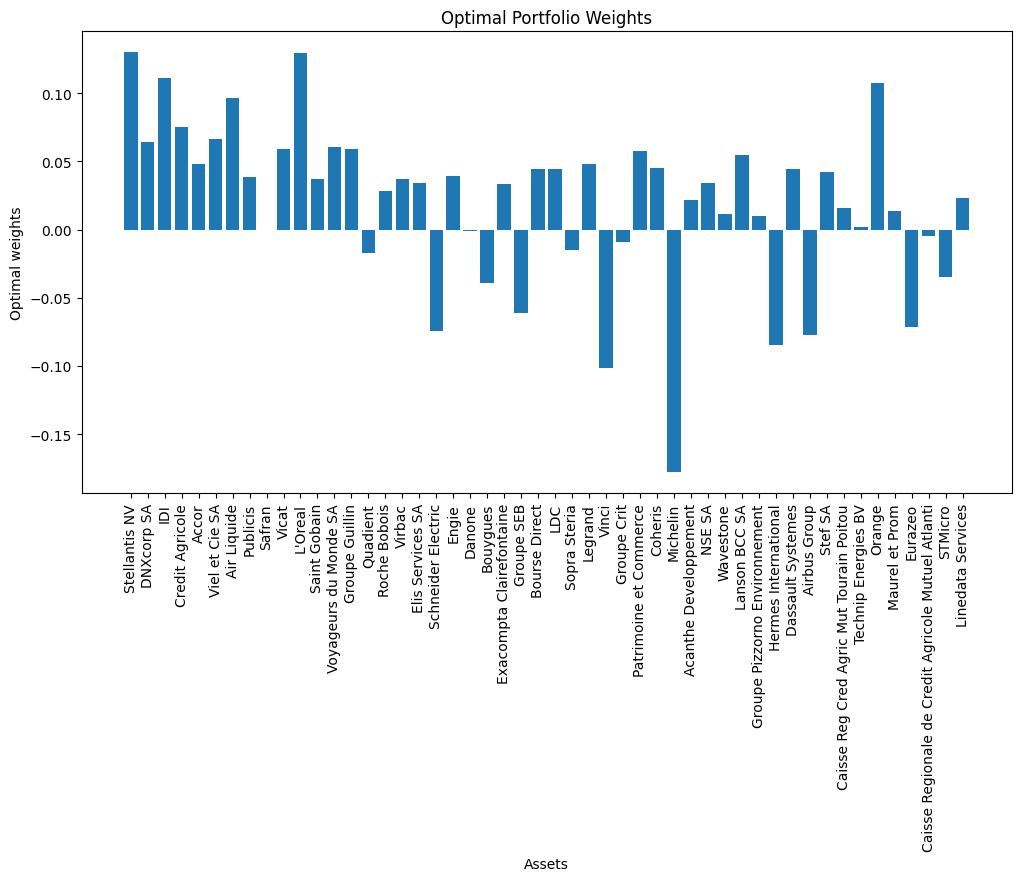

In [32]:
# DISPLAY OPTIMIZATION RESULTS
plt.figure(figsize=(12,6))
plt.bar(log_returns.columns, optimal_weights)

plt.xlabel('Assets')
plt.xticks(rotation=90)
plt.ylabel('Optimal weights')
plt.title('Optimal Portfolio Weights')

plt.show()

In [33]:
var_info(initial_weights, log_returns, cov_matr, alphas, True)
print("\n"+"-"*10+"\n")
cvar_info(initial_weights, log_returns, cov_matr, alphas, True)

Estimation of VaR for optimal portfolio with risk level = 3
 - With probability = 90.0% looses will not exceed 0.0423.
 - With probability = 95.0% looses will not exceed 0.0512.
 - With probability = 99.0% looses will not exceed 0.0752.
Estimation of VaR for optimal portfolio with risk level = 4
 - With probability = 90.0% looses will not exceed 0.0064.
 - With probability = 95.0% looses will not exceed 0.0090.
 - With probability = 99.0% looses will not exceed 0.0145.
Estimation of VaR for optimal portfolio with risk level = 5
 - With probability = 90.0% looses will not exceed 0.0041.
 - With probability = 95.0% looses will not exceed 0.0058.
 - With probability = 99.0% looses will not exceed 0.0095.
Estimation of VaR for optimal portfolio with risk level = 10
 - With probability = 90.0% looses will not exceed 0.0036.
 - With probability = 95.0% looses will not exceed 0.0047.
 - With probability = 99.0% looses will not exceed 0.0076.

----------

Estimation of CVaR for optimal portfol

#### Характеристика портфеля (короткие продажи разрешены):



1) Портфель с коэффициентом отверждения риска = 5 по сравнению с портфелем, где короткие продажи запрещены, имеет более высокую доходность с чуть более высоким риском: 44,5% против 35,6% в доходности и 7,6% против 6,8% в риске соответственно. Это становится возможным за счёт расширения пространства допустимых портфелей, которое является следствием разрешения торговли короткими позициями.
2) Портфель в себе содержит все 50 доступных активов, но с разной долей.
По прежнему активы с небольшим риском занимают бОльшую долю в портфеле среди длинных позиций: Stellantis NV, L'Oreal, Orange. Среди коротких позиций наибольшую долю занимают Michelin и Vinci. Это объясняется тем, что активы сильно коррелировали с портфелем, имели низкую доходность на изучаемом периоде и их риск не компенсировался доходностью.
Stellantis NV - мультинациональный производитель автомобилей
L'Oreal - мировой производитель уходовой косметики
Michelin - глобальный производитель покрышек и автомобильных решений.
Vinci - мировой лидер в сфере городского строительства.

3) Активы с относительно низкой доходностью и выссокой корреляцией с основными источниками риска используются в качестве хеджирующих инструментов, что приводит к добавлению коротких позиций в портфель. А их доля тем выше, чем сильнее тот или иной актив коррелирует с остальными.
4) VaR портфелей с короткими позициями при сопоставимых уровнях отвержения риска показывает худшее значение. Это происходит за счёт того, что при коротких позициях фактически нет ограничений, и цена может вырасти или упасть на сколько угодно много, поэтому хвостовой риск портфеля увеличивается
<br>

In [34]:
# VISUALAZATION
# Map of stocks with efficient frontier and 4 optimal portfolios

# Some important variables
returns_mean = log_returns.mean()*254
returns_std = log_returns.std()*np.sqrt(254)
asset_names = log_returns.columns.values
portf_info = portfolio_info(initial_weights, log_returns, cov_matr, alphas, True)

idx = np.argsort(portf_info['portfolio_risk'])
risk_sorted = portf_info['portfolio_risk'].iloc[idx].values
return_sorted = portf_info['expected_return'].iloc[idx].values
E_frontier = np.maximum.accumulate(return_sorted)
many_ret, many_vol = many_portfolios(initial_weights, log_returns, cov_matr, alphas, 20, True)

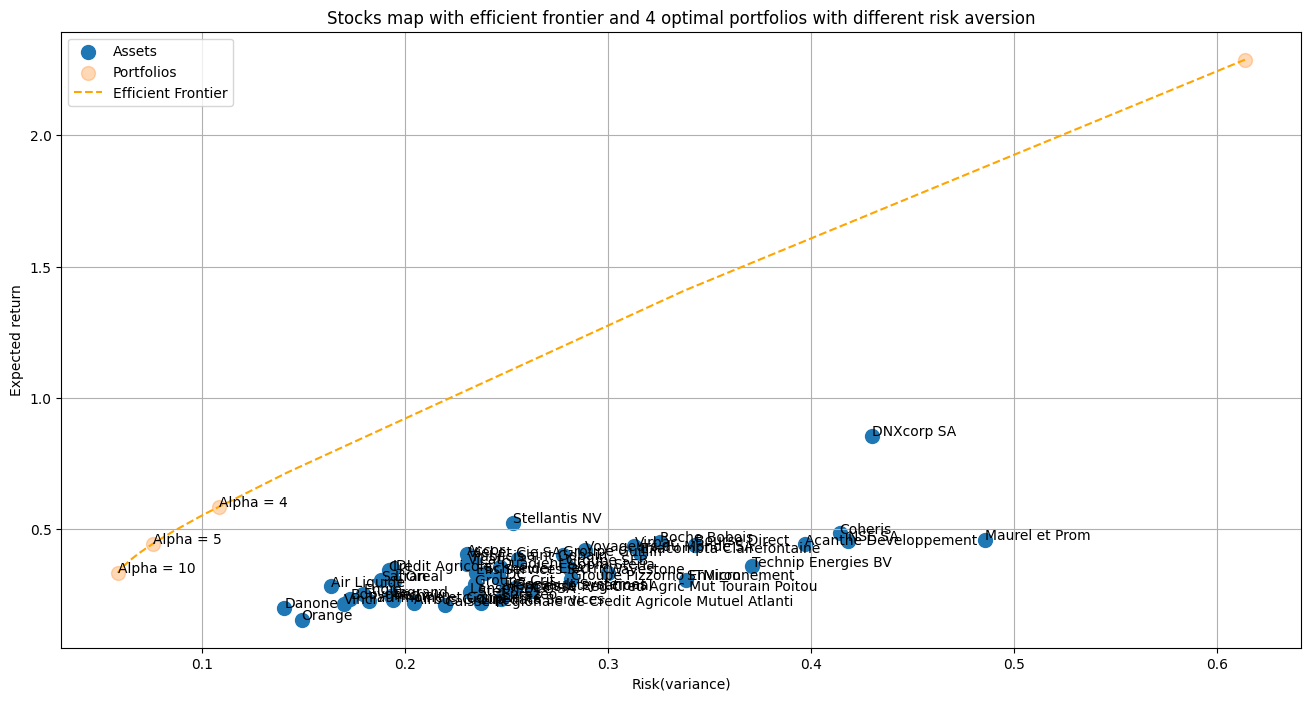

In [35]:
visualize(alphas, returns_std, returns_mean, asset_names, portf_info, risk_sorted, return_sorted, many_ret, many_vol)

Наш эффективный фронт портфелей с короткими продажами ничем не ограничен, поэтому график растёт сильно вверх за счёт увеличившегося пространства допустимых портфелей

### Задание 4: Markowitz-Tobin model.
Рассмотрите набор активов, отобранных в п.2 (10 активов). Выберете
безрисковый актив (можно виртуальный). Постройте рыночный (оптимальный) портфель. Сделайте
анализ долей активов рыночного портфеля. Оцените VaR и CVaR портфеля. Сделайте выводы.
Рассмотрите два случая:
- короткие продажи разрешены,
- короткие продажи запрещены.

### Решение:


In [36]:
# Get lognormal returns
log_returns_10 = (np.log(selected_stocks_10.iloc[:,1:]/selected_stocks_10.iloc[:,1:].shift(1))).dropna()

# Calculate covariance matrix
cov_matr_10 = log_returns_10.cov()*254

# Treasury rate is taken from here: https://www.investing.com/rates-bonds/france-10-year-bond-yield-historical-data
risk_free_rate = RISK_FREE_RATE

В модели Марковица-Тобина мы оптимизируем веса портфеля, чтобы получить оптимальный портфель. Также нам доступен выбор безрискового актива. И смысл в том, чтобы построить CML (Capital Market Line), которая соединит оптимальный портфель и безрисковый актив, что позволит нам выбирать, в каком соотношении составить смешанный портфель. CML также является касательной к эффективному фронту. <br>
Задача оптимизации отношения Шарпа:
$$ \frac{E(w) - E_F}{\sigma(w)} -> max $$
где $$ \Sigma w_i=1$$ и $$w_i \geq 0$$ если короткие продажи запрещены. <br><br>
Доход смешанного портфеля находится по следующей формуле:
$$ R_{mixed} = \mu E_F + (1-\mu) R_{Sharp} $$
$$где \: \mu - доля \: капитала \: в \: безрисковом \: активе$$

In [37]:
# OPTIMIZATION
# optimal portfolio is calculated by maximazing sharp ratio
def sharp_ratio(weights, log_ret, cov_matr, risk_free):
  return ((exp_ret(log_ret, weights) - risk_free) / std_dev(cov_matr, weights))

def neg_sharp(weights, log_ret, cov_matr, risk_free):
  return -sharp_ratio(weights, log_ret, cov_matr, risk_free)

# Set constraints
constraints = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
bounds_s = [(-1, 1) for _ in range(len(log_returns_10.columns))] # short positions are allowed
bounds_l = [(0, 1) for _ in range(len(log_returns_10.columns))] # short positions are not allowed

# Set initial weights
initial_weights = np.array([1/len(log_returns_10.columns)] * len(log_returns_10.columns))

# SHORT POSITIONS ARE RESTRICTED
# Optimize weights to maximize Sharp Ratio
# SLSQ - Sequential Least Squares Quadratic Programming
optimized_results = minimize(neg_sharp, initial_weights, args=(log_returns_10, cov_matr_10, risk_free_rate), method='SLSQP', constraints=constraints, bounds=bounds_l)
optimal_weights_10 = optimized_results.x

In [38]:
# PRINTING OPTIMIZATION RESULTS
print('Optimal weights:')

optimal_portfolio_return = exp_ret(log_returns_10, optimal_weights_10)
optimal_portfolio_volatility = std_dev(cov_matr_10, optimal_weights_10)
optimal_sharp_ratio = sharp_rat(optimal_weights_10, log_returns_10, cov_matr_10)

print(f"Expected annual return: {optimal_portfolio_return:.4f}")
print(f"Expected volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharp Ratio: {optimal_sharp_ratio:.4f}")

Optimal weights:
Expected annual return: 0.2832
Expected volatility: 0.0690
Sharp Ratio: 4.1011


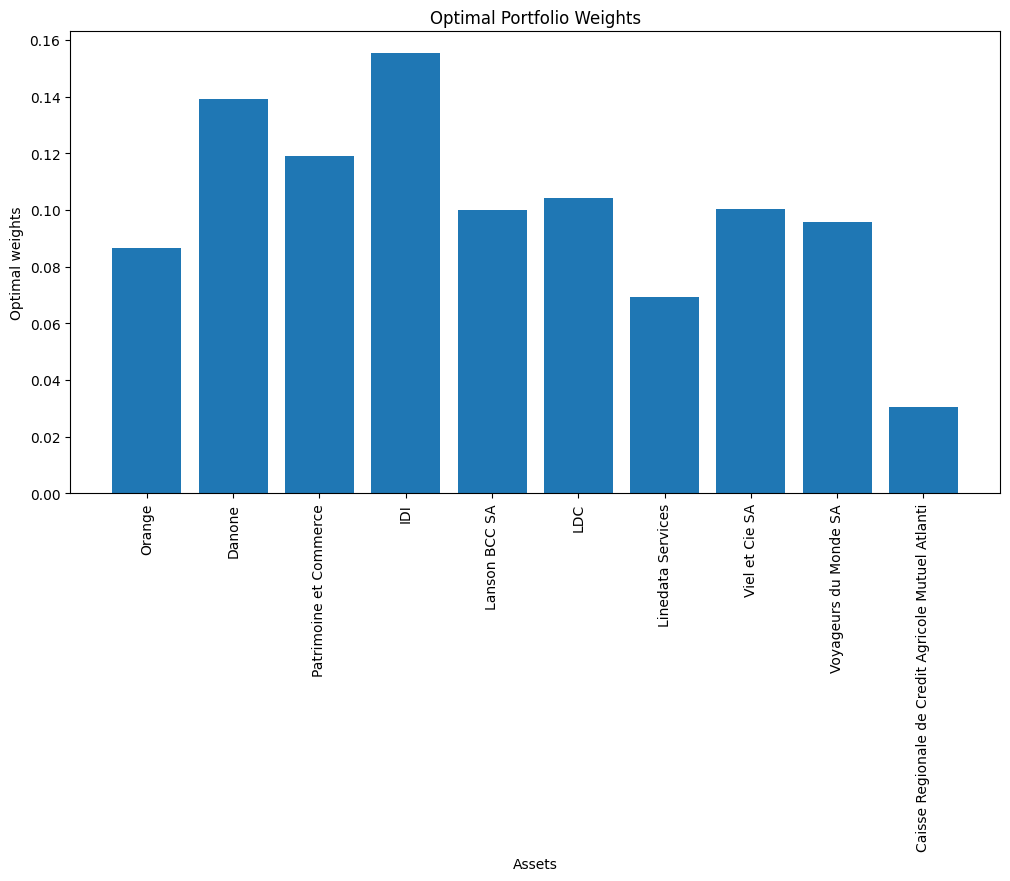

In [39]:
# DISPLAY OPTIMIZATION RESULTS
plt.figure(figsize=(12,6))
plt.bar(log_returns_10.columns, optimal_weights_10)

plt.xlabel('Assets')
plt.xticks(rotation=90)
plt.ylabel('Optimal weights')
plt.title('Optimal Portfolio Weights')

plt.show()

In [40]:
print(f"Optimal portfolio VaR(p=0.95) = {portfolio_var(optimal_weights_10, log_returns_10, 0.95):.4f}")
print(f"CVaR = {portfolio_cvar(optimal_weights_10, log_returns_10, 0.95):.4f}")

Optimal portfolio VaR(p=0.95) = 0.0065
CVaR = 0.0081


#### Характеристика портфеля (короткие продажи запрещены):
1) В портфеле 10-ти акций, составленным оптимальным образом с применением отношения Шарпа, лидирующие позиции снова заняли IDI и Danone. Эти компании имеют низкий уровень риска, что говорит о их стабильности.
2) В целом выбор долей активов обусловлен максимизацией соотношения доходности к риску, что означает подбор акций с наисвышей доходностью на единицу риска


In [41]:
# VISUALAZATION
# Map of stocks with Capital Market Line and optimal portfolio

# Some important variables
returns_mean = log_returns_10.mean()*254
returns_std = log_returns_10.std()*np.sqrt(254)
asset_names = log_returns_10.columns.values

def visualize_10(returns_std, returns_mean, asset_names, optimal_portfolio_volatility, optimal_portfolio_return, risk_free_rate):
  plt.figure(figsize=(16,8))
  plt.scatter(
      returns_std,
      returns_mean,
      marker = "o",
      s=100,
      label = "Assets"
  )
  for i, name in enumerate(asset_names):
    plt.text(returns_std[i], returns_mean[i], name)

  # optimal portfolio
  plt.scatter(
      optimal_portfolio_volatility,
      optimal_portfolio_return,
      s=100,
      alpha=0.3,
      label="Optimal portfolio"
  )

  plt.scatter(
      0,
      risk_free_rate,
      s=100,
      alpha=0.3,
      label="Risk-free investment"
  )

  # CML
  mix = np.linspace(0,1.5,100)
  cml_risk = []
  cml_return = []
  for m in mix:
    w_combined = m*optimal_weights_10
    r = m*optimal_portfolio_return + (1-m)*risk_free_rate
    s = abs(m)*optimal_portfolio_volatility
    cml_risk.append(s)
    cml_return.append(r)

  plt.plot(
      cml_risk,
      cml_return,
      linestyle="--",
      color="orange",
      label="Capital Market Line"
  )

  plt.xlabel("Risk(variance)")
  plt.ylabel("Expected return")
  plt.title("Stocks map with Capital Market Line and optimal portfolio")
  plt.legend()
  plt.grid(True)
  plt.show()

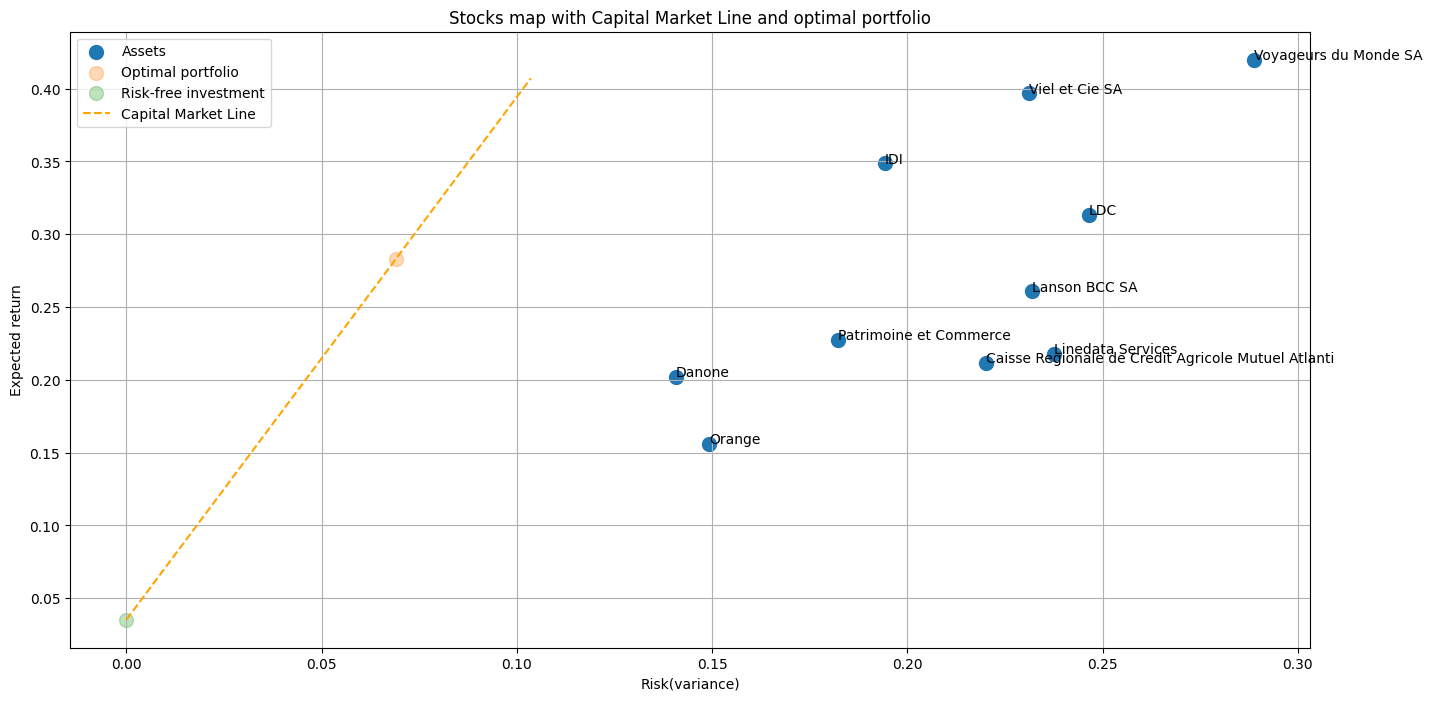

In [42]:
visualize_10(returns_std, returns_mean, asset_names, optimal_portfolio_volatility, optimal_portfolio_return, risk_free_rate)

Capital Market Line соединила безрисковый актив с доходностью 0.035 годовых с оптимальным портфелем из 10 активов. Выбор доли содержания безрискового актива позволяет сформировать смешанный портфель, значение дохода и риска которого лежит на приведённой CML.

In [43]:
# SHORT POSITIONS ARE PERMITTED
optimized_results = minimize(neg_sharp, initial_weights, args=(log_returns_10, cov_matr_10, risk_free_rate), method='SLSQP', constraints=constraints, bounds=bounds_s)
optimal_weights_10_s = optimized_results.x

In [44]:
# PRINTING OPTIMIZATION RESULTS
print('Optimal weights:')

optimal_portfolio_return = exp_ret(log_returns_10, optimal_weights_10_s)
optimal_portfolio_volatility = std_dev(cov_matr_10, optimal_weights_10_s)
optimal_sharp_ratio = sharp_rat(optimal_weights_10_s, log_returns_10, cov_matr_10)

print(f"Expected annual return: {optimal_portfolio_return:.4f}")
print(f"Expected volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharp Ratio: {optimal_sharp_ratio:.4f}")

Optimal weights:
Expected annual return: 0.2832
Expected volatility: 0.0690
Sharp Ratio: 4.1011


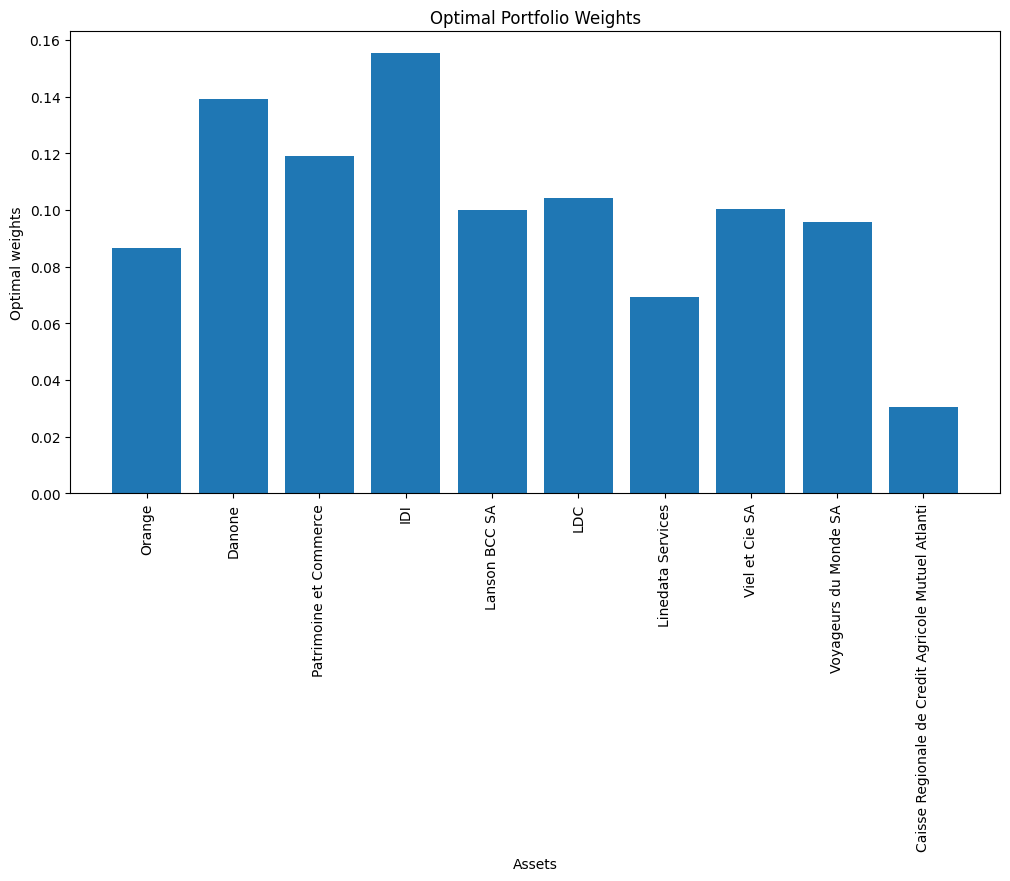

In [45]:
# DISPLAY OPTIMIZATION RESULTS
plt.figure(figsize=(12,6))
plt.bar(log_returns_10.columns, optimal_weights_10_s)

plt.xlabel('Assets')
plt.xticks(rotation=90)
plt.ylabel('Optimal weights')
plt.title('Optimal Portfolio Weights')

plt.show()

In [46]:
print(f"Optimal portfolio VaR(p=0.95) = {portfolio_var(optimal_weights_10_s, log_returns_10, 0.95):.4f}")
print(f"CVaR = {portfolio_cvar(optimal_weights_10_s, log_returns_10, 0.95):.4f}")

Optimal portfolio VaR(p=0.95) = 0.0065
CVaR = 0.0081


#### Характеристика портфеля (короткие продажи разрешены):
Состав портфеля при разрешении коротких продаж (и доходности безрискового актива = 0.035) соответствует составу портфеля без коротких продаж, так как при заданных характеристиках активов использование коротких позиций не улучшает отношение Шарпа.
При увеличении доходности безрискового актива состав портфеля меняется и некоторые позиции шортятся.


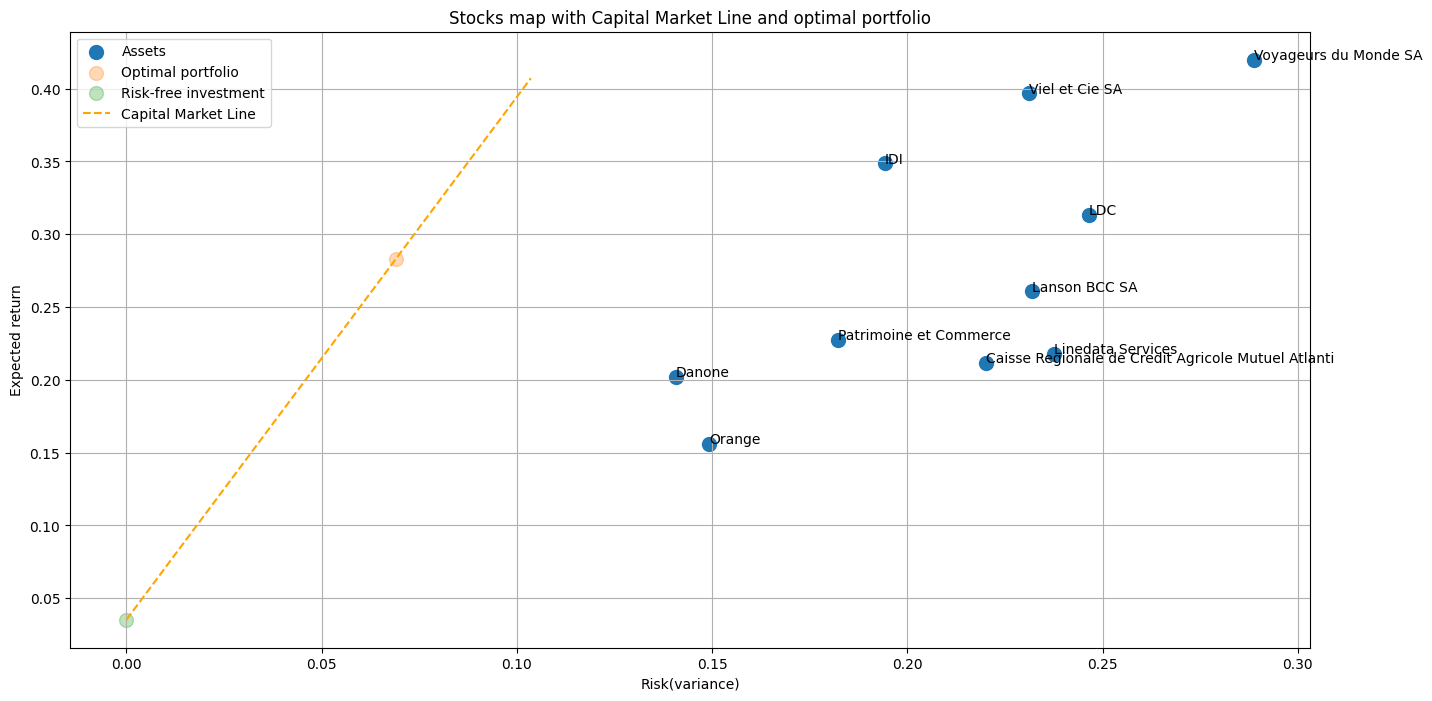

In [47]:
visualize_10(returns_std, returns_mean, asset_names, optimal_portfolio_volatility, optimal_portfolio_return, risk_free_rate)

###Задание 5: One factor model.
Рассмотрите набор активов, отобранных в п.2 (10 активов). Проверьте
выполнение условий модели с одним фактором, выбрав в качестве фактора индекс рынка. Считая
модель адекватной найдите рыночный портфель для этого набора активов (воспользуйтесь формулой
весов оптимального портфеля в модели с одним фактором). Сравните его с портфелем п.4.

In [48]:
stocks_df = pd.read_csv('selected_stocks_10.csv', sep=';', encoding='utf-8-sig')
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'], format='%Y-%m-%d')
stocks_df.set_index('Date', inplace=True)

In [49]:
# Выравниваем по датам
common_dates = stocks_df.index.intersection(cac40_df.index)
stocks_aligned = stocks_df.loc[common_dates]
cac40_aligned = cac40_df.loc[common_dates]

# Расчет логарифмических доходностей
stock_returns = np.log(stocks_aligned / stocks_aligned.shift(1)).dropna()
market_returns = np.log(cac40_aligned / cac40_aligned.shift(1)).dropna()

# Синхронизируем
final_idx = stock_returns.index.intersection(market_returns.index)
stock_returns = stock_returns.loc[final_idx]
market_returns = market_returns.loc[final_idx]

In [50]:
# Избыточные доходности
excess_stock = stock_returns - risk_free_daily
excess_market = market_returns['Price'] - risk_free_daily

# Регрессии CAPM
capm_results = []
for asset in stock_returns.columns:
    y = excess_stock[asset]
    X = sm.add_constant(excess_market)
    model = sm.OLS(y, X, missing='drop').fit()

    capm_results.append({
        'Актив': asset,
        'Alpha': model.params['const'],
        'Beta': model.params['Price'],
        'R2': model.rsquared,
        'p_Alpha': model.pvalues['const'],
        'p_Beta': model.pvalues['Price']
    })

# DataFrame с результатами
results_df = pd.DataFrame(capm_results)
results_df.set_index('Актив', inplace=True)

print("Результаты CAPM:")
print(results_df[['Beta', 'R2', 'p_Beta']].round(4))

Результаты CAPM:
                                                      Beta      R2  p_Beta
Актив                                                                     
Orange                                              0.1426  0.0175  0.0350
Danone                                              0.2988  0.0865  0.0000
Patrimoine et Commerce                              0.1990  0.0229  0.0159
IDI                                                 0.0463  0.0011  0.6004
Lanson BCC SA                                       0.0728  0.0019  0.4902
LDC                                                 0.1418  0.0064  0.2053
Linedata Services                                   0.2457  0.0205  0.0224
Viel et Cie SA                                      0.1898  0.0130  0.0702
Voyageurs du Monde SA                               0.1300  0.0039  0.3220
Caisse Regionale de Credit Agricole Mutuel Atlanti  0.1918  0.0146  0.0546


In [51]:
# Статистические показатели
significant_betas = (results_df['p_Beta'] < 0.05).sum()
mean_r2 = results_df['R2'].mean()
mean_beta = results_df['Beta'].mean()

print(f"Значимые Beta (p < 0.05): {significant_betas} из {len(results_df)}")
print(f"Средний R^2: {mean_r2:.4f}")
print(f"Средняя Beta: {mean_beta:.4f}")

Значимые Beta (p < 0.05): 4 из 10
Средний R^2: 0.0188
Средняя Beta: 0.1659


In [52]:
# Годовые ковариация и ожидаемые доходности
cov_matrix = excess_stock.cov() * TRADING_DAYS
expected_returns = excess_stock.mean() * TRADING_DAYS
cov_inv = np.linalg.inv(cov_matrix.values)
numerator = cov_inv @ expected_returns.values
denominator = np.sum(numerator)
market_weights = numerator / denominator

# DataFrame с весами
weights_df = pd.DataFrame({
    'Актив': results_df.index,
    'Вес': market_weights
}).sort_values('Вес', ascending=False)

weights_df['Вес_%'] = weights_df['Вес'].apply(lambda x: f"{x:.2%}")

print("Веса рыночного портфеля:")
print(weights_df[['Актив', 'Вес_%']].to_string(index=False))

Веса рыночного портфеля:
                                             Актив  Вес_%
                                               IDI 15.52%
                                            Danone 13.91%
                            Patrimoine et Commerce 11.90%
                                               LDC 10.42%
                                    Viel et Cie SA 10.02%
                                     Lanson BCC SA 10.01%
                             Voyageurs du Monde SA  9.57%
                                            Orange  8.67%
                                 Linedata Services  6.94%
Caisse Regionale de Credit Agricole Mutuel Atlanti  3.04%


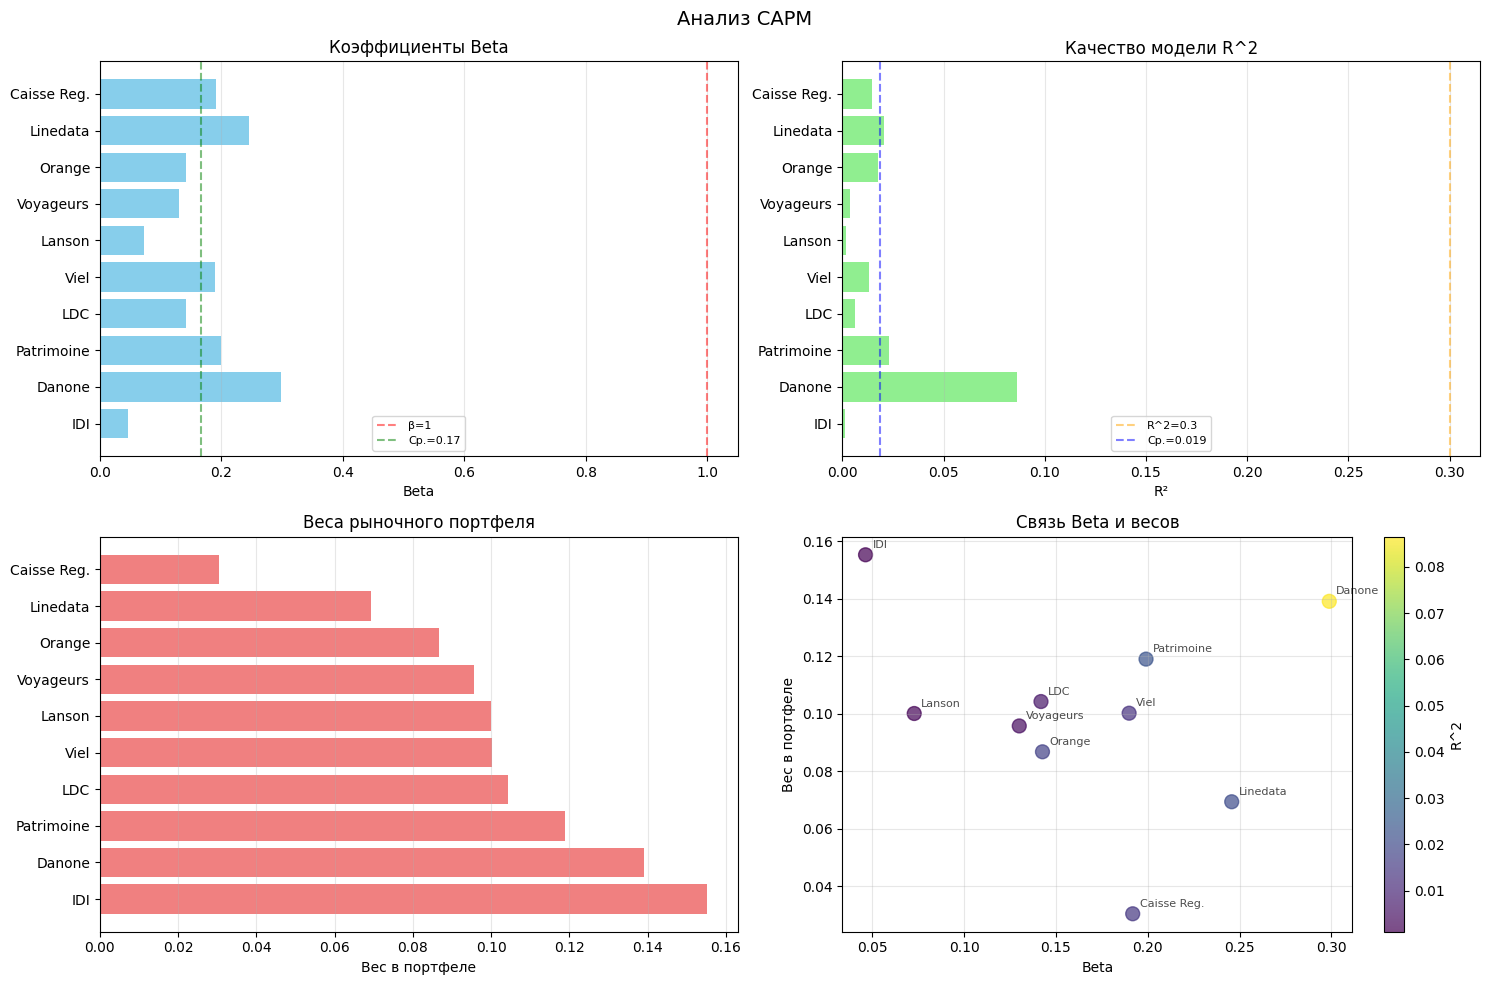

In [53]:
import matplotlib.pyplot as plt

# Сортируем по весам для согласованности графиков
weights_sorted = weights_df.sort_values('Вес', ascending=False)
sorted_assets = weights_sorted['Актив'].tolist()

# Короткие имена для графиков
short_names = {
    'Orange': 'Orange',
    'Danone': 'Danone',
    'Patrimoine et Commerce': 'Patrimoine',
    'IDI': 'IDI',
    'Lanson BCC SA': 'Lanson',
    'LDC': 'LDC',
    'Linedata Services': 'Linedata',
    'Viel et Cie SA': 'Viel',
    'Voyageurs du Monde SA': 'Voyageurs',
    'Caisse Regionale de Credit Agricole Mutuel Atlanti': 'Caisse Reg.'
}
sorted_names = [short_names.get(a, a) for a in sorted_assets]

# Данные в едином порядке
ordered_betas = [results_df['Beta'][a] for a in sorted_assets]
ordered_r2 = [results_df['R2'][a] for a in sorted_assets]
ordered_weights = weights_sorted['Вес'].tolist()

# Создаем графики
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Beta
axes[0,0].barh(sorted_names, ordered_betas, color='skyblue')
axes[0,0].axvline(x=1, color='r', linestyle='--', alpha=0.5, label='β=1')
axes[0,0].axvline(x=mean_beta, color='g', linestyle='--', alpha=0.5, label=f'Ср.={mean_beta:.2f}')
axes[0,0].set_xlabel('Beta')
axes[0,0].set_title('Коэффициенты Beta')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3, axis='x')

# 2. R^2
axes[0,1].barh(sorted_names, ordered_r2, color='lightgreen')
axes[0,1].axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='R^2=0.3')
axes[0,1].axvline(x=mean_r2, color='blue', linestyle='--', alpha=0.5, label=f'Ср.={mean_r2:.3f}')
axes[0,1].set_xlabel('R²')
axes[0,1].set_title('Качество модели R^2')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3, axis='x')

# 3. Веса портфеля
axes[1,0].barh(sorted_names, ordered_weights, color='lightcoral')
axes[1,0].set_xlabel('Вес в портфеле')
axes[1,0].set_title('Веса рыночного портфеля')
axes[1,0].grid(True, alpha=0.3, axis='x')

# 4. Связь Beta и весов
scatter = axes[1,1].scatter(ordered_betas, ordered_weights, s=100, c=ordered_r2, cmap='viridis', alpha=0.7)
axes[1,1].set_xlabel('Beta')
axes[1,1].set_ylabel('Вес в портфеле')
axes[1,1].set_title('Связь Beta и весов')
axes[1,1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1,1]).set_label('R^2')

# Подписи точек
for i, (x, y, name) in enumerate(zip(ordered_betas, ordered_weights, sorted_names)):
    axes[1,1].annotate(name, (x, y), xytext=(5,5), textcoords='offset points', fontsize=8, alpha=0.7)

# Общий заголовок
plt.suptitle(f'Анализ CAPM', fontsize=14)
plt.tight_layout()
plt.show()

### Индекс рынка.
Разберитесь, как составляется портфель индекса (определите веса, с которыми
активы входят в индекс). Дайте характеристику индекса (гистограмма, распределение, выбросы).
Найдите собственные значения матрицы ковариаций активов индекса. Что необычного в
распределении собственных значений? На основе метода главных компонент предложите свою
модель индекса рынка. Сравните ваш индекс с индексом рынка.

In [54]:
# --- ЗАГРУЗКА И ОЧИСТКА ДАННЫХ ---

# Загружаем активы (пропускаем технические строки, меняем запятые на точки)
assets = pd.read_csv('CAC_40.csv', sep=';', skiprows=2, index_col=0, dayfirst=True)
assets = assets.replace(r'[\s\xa0]', '', regex=True).replace(',', '.', regex=True).astype(float)
assets.index = pd.to_datetime(assets.index, dayfirst=True)

# Загружаем сам индекс
index_df = pd.read_csv('CAC40.csv', sep=';', index_col='Date', dayfirst=True)
index_df.index = pd.to_datetime(index_df.index, dayfirst=True)

# Синхронизируем даты и считаем доходности
data = pd.concat([assets, index_df], axis=1).dropna()
returns = np.log(data / data.shift(1)).dropna()

X = returns.drop(columns=['Price']) # Доходности акций
y = returns['Price']              # Доходность индекса

# --- 1. ОПРЕДЕЛЕНИЕ ВЕСОВ ---
model_weights = LinearRegression(fit_intercept=False)
model_weights.fit(X, y)

weights = pd.Series(model_weights.coef_, index=X.columns)
print("Топ-5 активов по весу в индексе:")
print(weights.sort_values(ascending=False).head(5))

Топ-5 активов по весу в индексе:
733,60    0.115010
61,60     0.087279
89,76     0.064036
450,65    0.061968
181,78    0.057725
dtype: float64


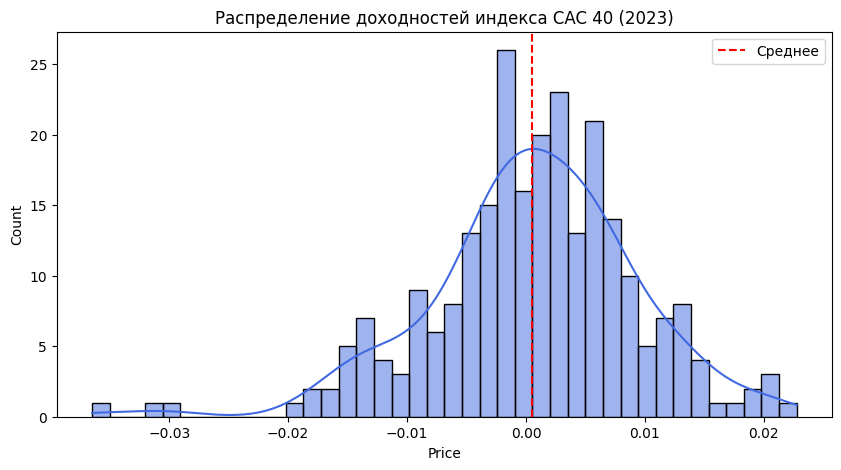

Средняя доходность: 0.000527
Волатильность: 0.008710
Выбросы (более 3-х сигм): 3 дней


In [55]:
# --- 2. ГИСТОГРАММА И ВЫБРОСЫ ---
plt.figure(figsize=(10, 5))
sns.histplot(y, kde=True, bins=40, color='royalblue')
plt.title('Распределение доходностей индекса CAC 40 (2023)')
plt.axvline(y.mean(), color='red', linestyle='--', label='Среднее')
plt.legend()
plt.show()

# Оценка нормальности и выбросов
z_scores = (y - y.mean()) / y.std()
outliers = y[np.abs(z_scores) > 3]

print(f"Средняя доходность: {y.mean():.6f}")
print(f"Волатильность: {y.std():.6f}")
print(f"Выбросы (более 3-х сигм): {len(outliers)} дней")

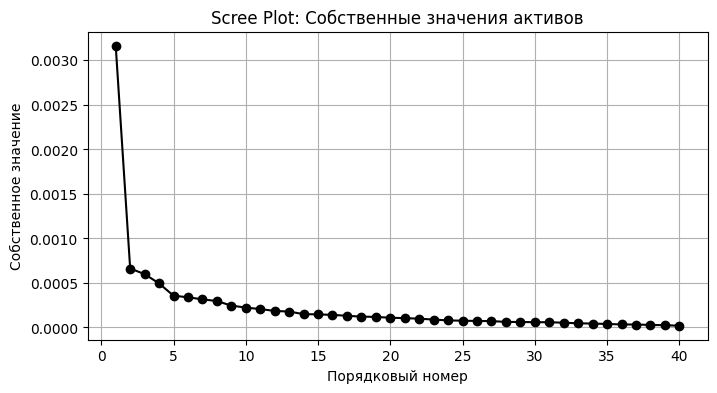

In [56]:
# --- 3. МАТРИЦА КОВАРИАЦИЙ И СОБСТВЕННЫЕ ЗНАЧЕНИЯ ---
cov_matrix = X.cov()
eigenvalues = np.linalg.eigvals(cov_matrix)
eigenvalues = sorted(eigenvalues, reverse=True)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='black')
plt.title('Scree Plot: Собственные значения активов')
plt.ylabel('Собственное значение')
plt.xlabel('Порядковый номер')
plt.grid(True)
plt.show()

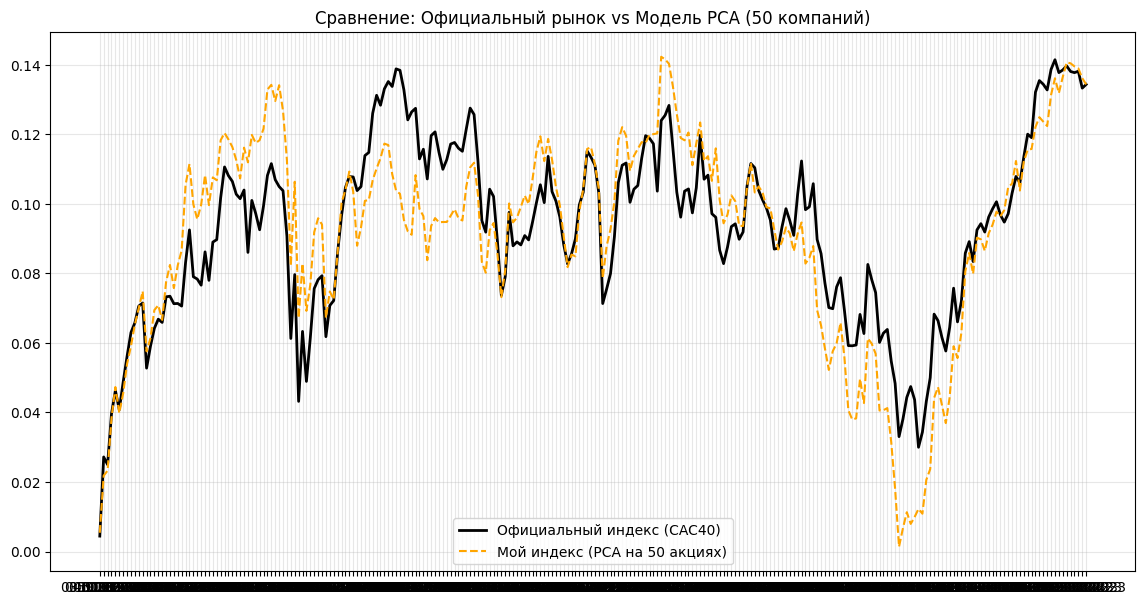

Корреляция между вашим индексом и CAC40: 0.8893


In [57]:
# 1. Загрузка данных 50 компаний и официального индекса
stocks_50 = pd.read_csv('french_stocks_50.csv', sep=';', index_col='Date', dayfirst=True)
market_index = pd.read_csv('CAC40.csv', sep=';', index_col='Date', dayfirst=True)

# 2. Расчет лог-доходностей
returns_50 = np.log(stocks_50 / stocks_50.shift(1)).dropna()
returns_market = np.log(market_index / market_index.shift(1)).dropna()

# Синхронизируем даты
common_dates = returns_50.index.intersection(returns_market.index)
X = returns_50.loc[common_dates]
y = returns_market.loc[common_dates]

# 3. Применяем PCA к 50 компаниям
pca = PCA(n_components=1)
# Наша модель индекса на основе 50 акций
my_index_pca = pca.fit_transform(X).flatten()

# Масштабируем для сравнения (чтобы волатильность совпадала)
my_index_scaled = (my_index_pca - my_index_pca.mean()) / my_index_pca.std() * y['Price'].std() + y['Price'].mean()

# 4. Визуальное сравнение
plt.figure(figsize=(14, 7))
plt.plot(y.index, y['Price'].cumsum(), label='Официальный индекс (CAC40)', color='black', linewidth=2)
plt.plot(y.index, my_index_scaled.cumsum(), label='Мой индекс (PCA на 50 акциях)', color='orange', linestyle='--')
plt.title('Сравнение: Официальный рынок vs Модель PCA (50 компаний)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Корреляция между вашим индексом и CAC40: {np.corrcoef(y['Price'], my_index_pca)[0,1]:.4f}")